# КИМ 3.1. Полносвязные сети (MLP) — эталонное решение

> **Это эталонное решение** для преподавателя. Студентам выдаётся ноутбук-задание
> [`kim-03-mlp.ipynb`](./kim-03-mlp.ipynb) без заполненных ячеек.
>
> Код ниже — один из возможных вариантов решения; не единственный и не обязательно
> оптимальный. Приводится для сверки и подготовки к защите.

---
## Часть А. Регрессия - California Housing

### 0. Импорт, воспроизводимость и выбор устройства

Один seed задаётся для NumPy, PyTorch и всех доступных CUDA-устройств.
Детерминированный режим cuDNN немного ограничивает оптимизации, зато повторный
запуск на том же оборудовании даёт воспроизводимый результат.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset, TensorDataset
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

%matplotlib inline

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin_memory = device.type == "cuda"
print(f"Устройство: {device}")

Устройство: cuda


### 1. Загрузка и разделение данных

`fetch_california_housing` возвращает 8 числовых признаков и медианную стоимость
дома. Цель уже выражена в сотнях тысяч долларов: значение `2.5` соответствует
примерно 250 000 долларов. Поэтому далее обозначаем её как нормализованную цель
$y_{norm}=price/100000$.

Сначала отделяем тестовые данные, затем выделяем validation из оставшейся части.
Тест используется ровно один раз - для итоговой оценки.

In [2]:
housing = fetch_california_housing()
X_all = housing.data.astype(np.float32)
y_all_norm = housing.target.astype(np.float32)

X_fit_raw, X_test_raw, y_fit_norm, y_test_norm = train_test_split(
    X_all, y_all_norm, test_size=0.20, random_state=SEED
)
X_train_raw, X_val_raw, y_train_norm, y_val_norm = train_test_split(
    X_fit_raw, y_fit_norm, test_size=0.20, random_state=SEED
)

print("train:", X_train_raw.shape)
print("validation:", X_val_raw.shape)
print("test:", X_test_raw.shape)
print("Признаки:", list(housing.feature_names))

train: (13209, 8)
validation: (3303, 8)
test: (4128, 8)
Признаки: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


### 2. Z-нормализация признаков только по train

Для каждого признака вычисляем $z=(x-\mu_{train})/\sigma_{train}$. Статистики
validation и test не участвуют в вычислении $\mu$ и $\sigma$: иначе информация о
будущих данных попадёт в подготовку модели. Те же train-статистики применяются ко
всем трём частям выборки. Цель дополнительно Z-нормализовать не требуется, потому
что она уже имеет удобный масштаб в единицах 100 000 долларов.

In [3]:
feature_mean = X_train_raw.mean(axis=0, keepdims=True)
feature_std = X_train_raw.std(axis=0, keepdims=True)

assert np.all(feature_std > 0), "Обнаружен константный признак"

X_train = ((X_train_raw - feature_mean) / feature_std).astype(np.float32)
X_val = ((X_val_raw - feature_mean) / feature_std).astype(np.float32)
X_test = ((X_test_raw - feature_mean) / feature_std).astype(np.float32)

print("Средние train после нормализации:", np.round(X_train.mean(axis=0), 4))
print("СКО train после нормализации:    ", np.round(X_train.std(axis=0), 4))

Средние train после нормализации: [ 0.  0. -0. -0. -0. -0. -0. -0.]
СКО train после нормализации:     [1. 1. 1. 1. 1. 1. 1. 1.]


### 3. DataLoader и архитектура `8 -> 64 -> 32 -> 1`

In [4]:
def make_regression_dataset(features, targets):
    return TensorDataset(
        torch.from_numpy(features),
        torch.from_numpy(targets).unsqueeze(1),
    )


regression_generator = torch.Generator().manual_seed(SEED)
train_reg_loader = DataLoader(
    make_regression_dataset(X_train, y_train_norm),
    batch_size=256,
    shuffle=True,
    generator=regression_generator,
    pin_memory=pin_memory,
)
val_reg_loader = DataLoader(
    make_regression_dataset(X_val, y_val_norm),
    batch_size=512,
    shuffle=False,
    pin_memory=pin_memory,
)
test_reg_loader = DataLoader(
    make_regression_dataset(X_test, y_test_norm),
    batch_size=512,
    shuffle=False,
    pin_memory=pin_memory,
)


class HousingMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(8, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.layers(x)


housing_model = HousingMLP().to(device)
print(housing_model)
print("Обучаемых параметров:", sum(p.numel() for p in housing_model.parameters()))

HousingMLP(
  (layers): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)
Обучаемых параметров: 2689


### 4. Обучение по MSE

Последний слой не имеет активации: задача регрессионная, поэтому выход не нужно
ограничивать. `MSELoss` усредняет квадраты ошибок по мини-батчу. После каждой эпохи
считаем train и validation MSE/MAE, сохраняя в памяти параметры с лучшим
validation MSE. Early stopping ограничивает время работы, а тестовая выборка в
выборе эпохи не участвует.

In [5]:
mse_loss = nn.MSELoss()
reg_optimizer = torch.optim.Adam(housing_model.parameters(), lr=1e-3)


def train_regressor_one_epoch(model, loader):
    model.train()
    squared_error_sum = 0.0
    absolute_error_sum = 0.0
    n = 0
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=pin_memory)
        yb = yb.to(device, non_blocking=pin_memory)

        reg_optimizer.zero_grad()
        predictions = model(xb)
        loss = mse_loss(predictions, yb)
        loss.backward()
        reg_optimizer.step()

        squared_error_sum += loss.item() * yb.numel()
        absolute_error_sum += (predictions.detach() - yb).abs().sum().item()
        n += yb.numel()
    return squared_error_sum / n, absolute_error_sum / n


@torch.inference_mode()
def evaluate_regressor(model, loader):
    model.eval()
    squared_error_sum = 0.0
    absolute_error_sum = 0.0
    n = 0
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=pin_memory)
        yb = yb.to(device, non_blocking=pin_memory)
        errors = model(xb) - yb
        squared_error_sum += errors.square().sum().item()
        absolute_error_sum += errors.abs().sum().item()
        n += yb.numel()
    return squared_error_sum / n, absolute_error_sum / n


MAX_EPOCHS = 100
PATIENCE = 15
train_mse_history = []
train_mae_history = []
val_mse_history = []
val_mae_history = []
best_val_mse = float("inf")
best_state = None
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_mse, train_mae = train_regressor_one_epoch(
        housing_model, train_reg_loader
    )
    val_mse, val_mae = evaluate_regressor(housing_model, val_reg_loader)
    train_mse_history.append(train_mse)
    train_mae_history.append(train_mae)
    val_mse_history.append(val_mse)
    val_mae_history.append(val_mae)

    if val_mse < best_val_mse:
        best_val_mse = val_mse
        best_state = {
            name: value.detach().cpu().clone()
            for name, value in housing_model.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Эпоха {epoch:3d}: train MSE={train_mse:.4f}, "
            f"val MSE={val_mse:.4f}, train MAE={train_mae:.4f}, "
            f"val MAE={val_mae:.4f}"
        )

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping на эпохе {epoch}")
        break

housing_model.load_state_dict(best_state)

Эпоха   1: train MSE=4.1087, val MSE=2.3484, train MAE=1.6849, val MAE=1.0197


Эпоха  10: train MSE=0.3858, val MSE=0.4085, train MAE=0.4412, val MAE=0.4527


Эпоха  20: train MSE=0.3337, val MSE=0.3696, train MAE=0.4045, val MAE=0.4278


Эпоха  30: train MSE=0.3073, val MSE=0.3385, train MAE=0.3852, val MAE=0.4038


Эпоха  40: train MSE=0.2926, val MSE=0.3300, train MAE=0.3740, val MAE=0.3976


...

Эпоха  70: train MSE=0.2716, val MSE=0.3114, train MAE=0.3608, val MAE=0.3871


Эпоха  80: train MSE=0.2675, val MSE=0.3025, train MAE=0.3570, val MAE=0.3788


Эпоха  90: train MSE=0.2623, val MSE=0.3050, train MAE=0.3541, val MAE=0.3749


Эпоха 100: train MSE=0.2581, val MSE=0.3027, train MAE=0.3508, val MAE=0.3736


<All keys matched successfully>

### 5. Кривые обучения

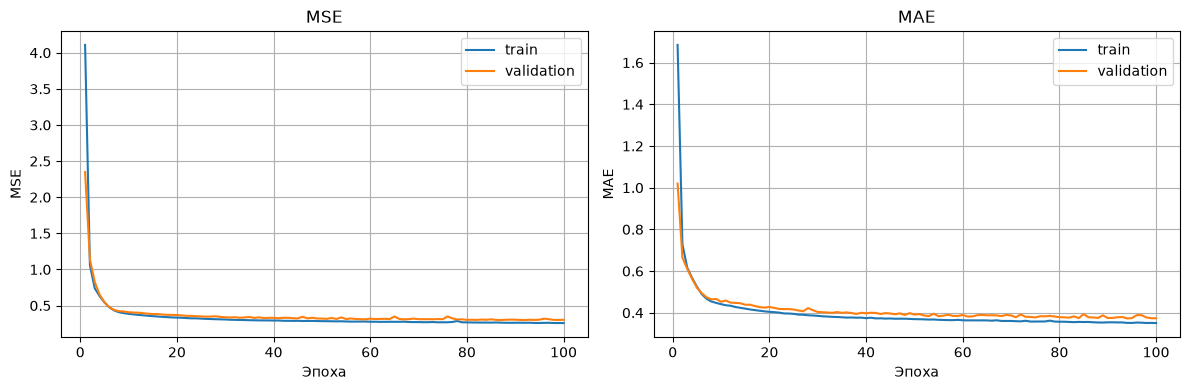

In [6]:
epochs_ran = np.arange(1, len(train_mse_history) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_ran, train_mse_history, label="train")
axes[0].plot(epochs_ran, val_mse_history, label="validation")
axes[0].set(title="MSE", xlabel="Эпоха", ylabel="MSE")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_ran, train_mae_history, label="train")
axes[1].plot(epochs_ran, val_mae_history, label="validation")
axes[1].set(title="MAE", xlabel="Эпоха", ylabel="MAE")
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

### 6. Итоговая оценка на test

MSE измеряется в квадрате нормализованной единицы цели, MAE - в единицах
100 000 долларов. Для интерпретации умножаем MAE на 100 000. MSE так переводить
нельзя: для него коэффициент масштаба пришлось бы возвести в квадрат.

In [7]:
test_mse_norm, test_mae_norm = evaluate_regressor(
    housing_model, test_reg_loader
)
TARGET_SCALE_DOLLARS = 100_000.0
test_mae_dollars = test_mae_norm * TARGET_SCALE_DOLLARS

print(f"Test MSE (нормализованная цель): {test_mse_norm:.4f}")
print(f"Test MAE (нормализованная цель): {test_mae_norm:.4f}")
print(f"Test MAE в долларах: ${test_mae_dollars:,.0f}")

Test MSE (нормализованная цель): 0.2935
Test MAE (нормализованная цель): 0.3724
Test MAE в долларах: $37,240


---
## Часть Б. Классификация - Fashion-MNIST

### 7. `torchvision` и DataLoader

`ToTensor` преобразует изображение `28 x 28` в `float32` диапазона `[0, 1]`, а
`Normalize` использует известные train-статистики Fashion-MNIST. Метки остаются
целыми индексами классов `0..9`, как требует `CrossEntropyLoss`. Seed генератора
фиксирует порядок перемешивания train; `seed_worker` фиксирует NumPy в workers.

Для сравнения архитектур используем все 50 000 train-объектов. Три сети получают
одинаковое число эпох и порядок объектов; дополнительное время является частью
обязательного сравнения архитектур и фиксируется в итоговой таблице.

In [8]:
from torchvision import datasets, transforms


fashion_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)),
])

fashion_train = datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=fashion_transform
)
fashion_test = datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=fashion_transform
)


def seed_worker(_worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)


BATCH_SIZE = 256
NUM_WORKERS = 2
ARCHITECTURE_TRAIN_SIZE = 50_000
subset_generator = torch.Generator().manual_seed(SEED)
architecture_indices = torch.randperm(
    len(fashion_train), generator=subset_generator
)[:ARCHITECTURE_TRAIN_SIZE].tolist()
fashion_architecture_train = Subset(fashion_train, architecture_indices)


def make_fashion_train_loader(seed):
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        fashion_architecture_train,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
        worker_init_fn=seed_worker,
        generator=generator,
        persistent_workers=NUM_WORKERS > 0,
    )


fashion_test_loader = DataLoader(
    fashion_test,
    batch_size=512,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
    worker_init_fn=seed_worker,
    persistent_workers=NUM_WORKERS > 0,
)

print("Train объектов:", len(fashion_train))
print("Используется в сравнении:", len(fashion_architecture_train))
print("Test объектов:", len(fashion_test))

Train объектов: 60000
Используется в сравнении: 50000
Test объектов: 10000


### 8. Три MLP-архитектуры

`Flatten` превращает изображение в вектор длины 784. Выход модели - 10
неограниченных чисел (**логитов**), поэтому `Softmax` в сеть не добавляется.
`CrossEntropyLoss` сама устойчиво вычисляет `LogSoftmax` и negative log-likelihood;
явный `Softmax` перед ней был бы и математически неверен, и менее устойчив.
Сравниваем компактную, широкую базовую и более глубокую сеть.

In [9]:
class FashionMLP(nn.Module):
    def __init__(self, hidden_sizes):
        super().__init__()
        layers = [nn.Flatten()]
        in_features = 28 * 28
        for hidden_size in hidden_sizes:
            layers.extend([nn.Linear(in_features, hidden_size), nn.ReLU()])
            in_features = hidden_size
        layers.append(nn.Linear(in_features, 10))
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        return self.layers(x)


classification_loss = nn.CrossEntropyLoss()
architecture_specs = [
    ('Компактная 784-128-10', [128]),
    ('Базовая 784-800-300-10', [800, 300]),
    ('Глубокая 784-512-256-128-10', [512, 256, 128]),
]

for name, hidden_sizes in architecture_specs:
    candidate = FashionMLP(hidden_sizes)
    parameters = sum(p.numel() for p in candidate.parameters())
    print(f'{name:<31}: {parameters:>9,} параметров')

Компактная 784-128-10          :   101,770 параметров
Базовая 784-800-300-10         :   871,310 параметров
Глубокая 784-512-256-128-10    :   567,434 параметров


### 9. Общий train/test протокол и замер времени

В train-цикле обязательны `model.train()`, обнуление градиентов, `backward()` и
шаг оптимизатора. В test-цикле используются `model.eval()` и `inference_mode()`:
градиенты не строятся, параметры не меняются. Класс выбирается через `argmax`
логитов; `Softmax` для accuracy также не нужен, поскольку он не меняет максимум.

Все архитектуры получают одинаковые seed, объекты, порядок mini-batches,
optimizer, batch size и десять эпох. Таймер охватывает только обучение; test
оценивается после его остановки и не входит во время обучения.

In [10]:
def train_classifier_one_epoch(model, loader, optimizer):
    model.train()
    loss_sum = 0.0
    correct = 0
    n = 0
    for images, labels in loader:
        images = images.to(device, non_blocking=pin_memory)
        labels = labels.to(device, non_blocking=pin_memory)

        optimizer.zero_grad()
        logits = model(images)
        loss = classification_loss(logits, labels)
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        loss_sum += loss.item() * batch_size
        correct += (logits.argmax(dim=1) == labels).sum().item()
        n += batch_size
    return loss_sum / n, correct / n


@torch.inference_mode()
def evaluate_classifier(model, loader):
    model.eval()
    loss_sum = 0.0
    correct = 0
    n = 0
    for images, labels in loader:
        images = images.to(device, non_blocking=pin_memory)
        labels = labels.to(device, non_blocking=pin_memory)
        logits = model(images)
        loss = classification_loss(logits, labels)

        batch_size = labels.size(0)
        loss_sum += loss.item() * batch_size
        correct += (logits.argmax(dim=1) == labels).sum().item()
        n += batch_size
    return loss_sum / n, correct / n


FASHION_EPOCHS = 10
architecture_results = []
architecture_histories = {}

for name, hidden_sizes in architecture_specs:
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    model = FashionMLP(hidden_sizes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    train_loader = make_fashion_train_loader(SEED)
    history = {'train_loss': [], 'train_accuracy': []}

    if device.type == 'cuda':
        torch.cuda.synchronize()
    started = time.perf_counter()
    for epoch in range(1, FASHION_EPOCHS + 1):
        train_loss, train_accuracy = train_classifier_one_epoch(
            model, train_loader, optimizer
        )
        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_accuracy)
        if epoch == 1 or epoch == FASHION_EPOCHS:
            print(
                f'{name}, эпоха {epoch:2d}/{FASHION_EPOCHS}: '
                f'loss={train_loss:.4f}, accuracy={train_accuracy:.4f}'
            )
    if device.type == 'cuda':
        torch.cuda.synchronize()
    train_seconds = time.perf_counter() - started

    test_loss, test_accuracy = evaluate_classifier(model, fashion_test_loader)
    architecture_histories[name] = history
    architecture_results.append({
        'architecture': name,
        'parameters': sum(p.numel() for p in model.parameters()),
        'test_loss': test_loss,
        'test_accuracy': test_accuracy,
        'train_seconds': train_seconds,
    })
    del train_loader

print(f"{'Архитектура':<31} {'параметры':>10} {'test acc':>9} {'время, с':>10}")
for row in architecture_results:
    print(
        f"{row['architecture']:<31} {row['parameters']:>10,} "
        f"{row['test_accuracy']:>9.4f} {row['train_seconds']:>10.2f}"
    )

highest_test_accuracy = max(
    architecture_results, key=lambda row: row['test_accuracy']
)
print('Наибольшая test accuracy:', highest_test_accuracy['architecture'])

Компактная 784-128-10, эпоха  1/10: loss=0.5552, accuracy=0.8066


Компактная 784-128-10, эпоха 10/10: loss=0.2493, accuracy=0.9074


Базовая 784-800-300-10, эпоха  1/10: loss=0.5062, accuracy=0.8166


Базовая 784-800-300-10, эпоха 10/10: loss=0.2092, accuracy=0.9216


Глубокая 784-512-256-128-10, эпоха  1/10: loss=0.5553, accuracy=0.7997


Глубокая 784-512-256-128-10, эпоха 10/10: loss=0.2184, accuracy=0.9189


Архитектура                      параметры  test acc   время, с
Компактная 784-128-10              101,770    0.8772      48.96
Базовая 784-800-300-10             871,310    0.8822      46.28
Глубокая 784-512-256-128-10        567,434    0.8756      44.45
Наибольшая test accuracy: Базовая 784-800-300-10


Test применяется здесь ровно так, как требует КИМ: для итогового
сравнения трёх заранее зафиксированных архитектур. После просмотра таблицы новые
гиперпараметры по этому test не подбираются. Время зависит от CPU/GPU, поэтому
интерпретируется вместе с числом параметров и измеряется в одном окружении.

### 10. Кривые обучения и вывод об архитектурах

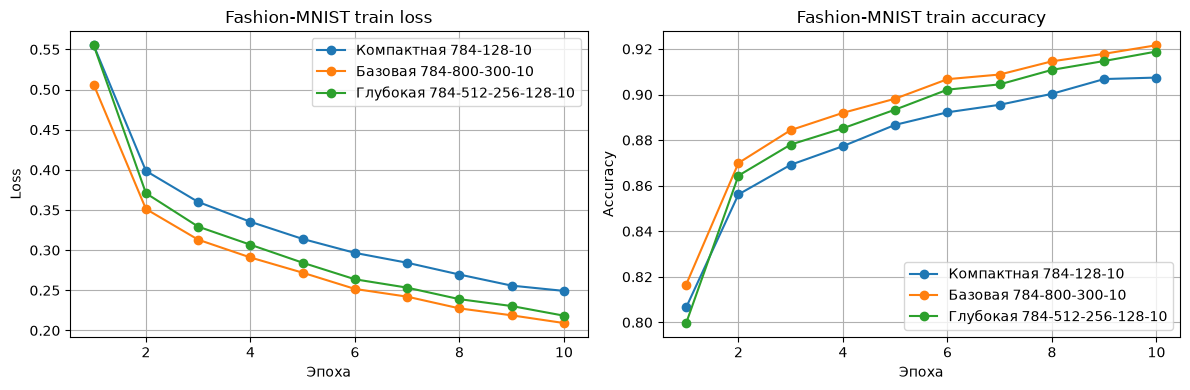

In [11]:
fashion_epochs = np.arange(1, FASHION_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, history in architecture_histories.items():
    axes[0].plot(fashion_epochs, history['train_loss'], marker='o', label=name)
    axes[1].plot(
        fashion_epochs, history['train_accuracy'], marker='o', label=name
    )
axes[0].set(title="Fashion-MNIST train loss", xlabel="Эпоха", ylabel="Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].set(
    title="Fashion-MNIST train accuracy", xlabel="Эпоха", ylabel="Accuracy"
)
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

**Вывод:** широкая или глубокая сеть не обязана быть лучшей: рост
ёмкости увеличивает время и риск переобучения, а выигрыш test accuracy может быть
мал. Компромисс следует выбирать по напечатанной таблице: сравнить прирост
`test_accuracy` с дополнительными параметрами и секундами обучения.

---
## Часть В. Универсальная теорема аппроксимации

**Универсальная теорема аппроксимации (UAT)** утверждает, что для любой
непрерывной функции на компактном множестве и любого $\varepsilon>0$ существует
полносвязная сеть с одним скрытым слоем и конечным числом нейронов, которая
приближает эту функцию с ошибкой меньше $\varepsilon$ (при подходящей нелинейной
активации; классические результаты используют сигмоидальную активацию, аналогичные
результаты есть и для ReLU).

Ключевая оговорка: **существование не равно находимости**. UAT говорит, что
подходящие веса существуют, но не предоставляет алгоритм их нахождения и не
гарантирует, что SGD или Adam найдёт их за конечное разумное время. Теорема также
не обещает:

- небольшую ширину сети или приемлемое число параметров;
- хорошую обусловленность задачи оптимизации и отсутствие плохих стационарных точек;
- обобщение на данные вне обучающей выборки;
- вычислительную эффективность полученного приближения.

Глубина не нужна для самого факта универсальности, однако для многих
композиционных функций глубокая сеть представляет решение значительно компактнее
мелкой. Поэтому UAT объясняет выразительность MLP, но практический успех всё равно
зависит от архитектуры, данных, оптимизатора и регуляризации.